In [ ]:
!pip install statsmodels kagglehub

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import zipfile
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Bidirectional, LSTM, Dense
from typing import Tuple
import matplotlib.pyplot as plt

In [ ]:
# --- Data Loading ---
def download_and_load_data() -> pd.DataFrame:
    """Download and load the Kaggle dataset."""
    try:
        path = kagglehub.dataset_download("shashanks1202/household-power-consumption-study")
        print("Dataset downloaded to:", path)

        # List files in the downloaded directory
        files = os.listdir(path)
        print("Files in downloaded directory:", files)

        # Check for zip files and extract if present
        zip_files = [f for f in files if f.endswith('.zip')]
        if zip_files:
            zip_path = os.path.join(path, zip_files[0])
            print("Extracting zip file:", zip_path)
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(path)
            # Update files list after extraction
            files = os.listdir(path)
            print("Files after extraction:", files)

        # Recursively search for Electricity_consumption.csv
        csv_file = None
        for root, dirs, files_in_dir in os.walk(path):
            print(f"Searching in: {root}")
            print(f"Files found: {files_in_dir}")
            for f in files_in_dir:
                if f == 'Electricity_consumption.csv':  # Exact match for expected file name
                    csv_file = os.path.join(root, f)
                    break
            if csv_file:
                break

        if not csv_file:
            raise FileNotFoundError("No 'Electricity_consumption.csv' file found in the downloaded dataset or its subdirectories.")

        print("Loading file:", csv_file)
        df = pd.read_csv(csv_file, sep=',',  # Use comma as separator
                         parse_dates={'Datetime': ['Date', 'Time']},
                         na_values='?')
        df.set_index('Datetime', inplace=True)
        return df
    except Exception as e:
        print(f"Error loading data: {str(e)}")
        return None


In [ ]:
# --- Data Preprocessing ---
def clean_and_transform_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean and transform the raw data."""
    try:
        df['Global_active_power_kWh'] = df['Global_active_power'] / 60
        df['day_of_week'] = df.index.dayofweek
        df['month'] = df.index.month
        df['is_holiday'] = df.index.isin(pd.to_datetime(['2025-12-25', '2025-01-01'])).astype(int)
        missing_percentage = df.isna().sum() / len(df) * 100
        print("Missing value percentages:\n", missing_percentage)
        df = df.fillna(method='ffill').fillna(method='bfill')
        return df
    except Exception as e:
        print(f"Error in data transformation: {str(e)}")
        return None

In [ ]:
def resample_to_period(df: pd.DataFrame, period: str = 'W') -> pd.DataFrame:
    """Resample data to weekly sums."""
    df_numeric = df.select_dtypes(include='number')
    return df_numeric.resample(period).sum()

In [ ]:
# --- Sequence Preparation ---
def prepare_sequences(df: pd.DataFrame, target_col: str = 'Global_active_power_kWh',
                     feature_cols: list = ['day_of_week', 'month'], look_back: int = 30) -> Tuple:
    """Prepare sequences for deep learning models."""
    try:
        target_scaler = MinMaxScaler()
        feature_scaler = MinMaxScaler()
        target_scaled = target_scaler.fit_transform(df[[target_col]])
        features_scaled = feature_scaler.fit_transform(df[feature_cols])
        X, y = [], []
        for i in range(look_back, len(df)):
            X.append(np.hstack([target_scaled[i-look_back:i], features_scaled[i-look_back:i]]))
            y.append(target_scaled[i, 0])
        X, y = np.array(X), np.array(y)
        X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))
        print(f"X shape: {X.shape}, y shape: {y.shape}")
        return X, y, target_scaler, feature_scaler
    except Exception as e:
        print(f"Error in sequence preparation: {str(e)}")
        return None, None, None, None

In [ ]:
# --- Data Splitting ---
def split_data(X: np.ndarray, y: np.ndarray, train_split: float = 0.8) -> Tuple:
    """Split data into train and test sets."""
    split_idx = int(train_split * len(X))
    return X[:split_idx], X[split_idx:], y[:split_idx], y[split_idx:]

In [ ]:
# --- Evaluation Metrics ---
def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Calculate evaluation metrics."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

In [ ]:
# --- Hybrid BSTS-CNN-BiLSTM Model ---
def build_cnn_bilstm(input_shape: tuple) -> Sequential:
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        Bidirectional(LSTM(50, return_sequences=True)),
        Bidirectional(LSTM(50)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def fit_bsts(df: pd.DataFrame, target_col: str = 'Global_active_power_kWh') -> dict:
    try:
        model = UnobservedComponents(
            df[target_col], level=True, seasonal=7, freq_seasonal=[{'period': 365.25, 'harmonics': 4}]
        )
        fitted_model = model.fit()
        return {
            'trend': fitted_model.level['smoothed'],
            'seasonal': fitted_model.seasonal['smoothed'],
            'forecast': fitted_model.forecast(steps=30),
            'model': fitted_model
        }
    except Exception as e:
        print(f"Error in BSTS fitting: {str(e)}")
        return None

def forecast_long_term(model, X_seed: np.ndarray, steps: int, target_scaler: MinMaxScaler) -> np.ndarray:
    predictions = []
    current_seq = X_seed[-1:]
    for _ in range(steps):
        pred = model.predict(current_seq, verbose=0)
        predictions.append(pred[0, 0])
        new_row = np.append(pred, current_seq[0, -1, 1:]).reshape(1, 1, -1)
        current_seq = np.append(current_seq[:, 1:, :], new_row, axis=1)
    return target_scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

In [ ]:
# --- CNN Baseline ---
def build_cnn(input_shape: tuple) -> Sequential:
    """Build a standalone CNN model."""
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def cnn_baseline(X_train, X_test, y_train, y_test, target_scaler):
    """Fit and evaluate a CNN model."""
    model = build_cnn(input_shape=(X_train.shape[1], X_train.shape[2]))
    model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)
    y_pred_scaled = model.predict(X_test, verbose=0)

    # Reshape y_pred_scaled to 2D before inverse transform
    y_pred_scaled = y_pred_scaled.reshape(-1, 1)

    y_pred = target_scaler.inverse_transform(y_pred_scaled)

    # Ensure y_test is 2D before inverse transform
    y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1))

    # Print the shapes of y_test_inv and y_pred for debugging
    print(f"Shape of y_test_inv: {y_test_inv.shape}")
    print(f"Shape of y_pred: {y_pred.shape}")

    # Check if shapes are compatible and truncate if necessary
    min_length = min(y_test_inv.shape[0], y_pred.shape[0])  # Get the minimum length
    y_test_inv = y_test_inv[:min_length]  # Truncate y_test_inv
    y_pred = y_pred[:min_length]  # Truncate y_pred

    metrics = calculate_metrics(y_test_inv, y_pred)
    print("\nCNN Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    return metrics

In [ ]:
# --- BiLSTM Baseline ---
def build_bilstm(input_shape: tuple) -> Sequential:
    """Build a standalone BiLSTM model."""
    model = Sequential([
        Bidirectional(LSTM(50, return_sequences=True), input_shape=input_shape),  # Added input_shape here
        Bidirectional(LSTM(50)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def bilstm_baseline(X_train, X_test, y_train, y_test, target_scaler):
    """Fit and evaluate a BiLSTM model."""
    model = build_bilstm(input_shape=(X_train.shape[1], X_train.shape[2]))
    model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = target_scaler.inverse_transform(y_pred_scaled)
    y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1))
    metrics = calculate_metrics(y_test_inv, y_pred)
    print("\nBiLSTM Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    return metrics

In [ ]:
# --- BSTS Baseline ---
def fit_bsts(df: pd.DataFrame, target_col: str = 'Global_active_power_kWh') -> dict:
    try:
        model = UnobservedComponents(
            df[target_col], level=True, seasonal=7, freq_seasonal=[{'period': 365.25, 'harmonics': 4}]
        )
        fitted_model = model.fit()

        # Get the last date in the data
        last_date = df.index[-1]

        # Create a date range for the forecast
        forecast_index = pd.date_range(start=last_date + pd.DateOffset(weeks=1), periods=30, freq='W')

        # Generate the forecast
        forecast = fitted_model.get_forecast(steps=30)
        forecast_values = forecast.summary_frame(alpha=0.05)['mean']  # Extract the mean forecast values

        # Attach the forecast index to the forecast Series
        forecast_values = pd.Series(forecast_values.values, index=forecast_index)

        return {
            'trend': fitted_model.level['smoothed'],
            'seasonal': fitted_model.seasonal['smoothed'],
            'forecast': forecast_values,  # Use the forecast with index
            'model': fitted_model
        }
    except Exception as e:
        print(f"Error in BSTS fitting: {str(e)}")
        return None

def bsts_baseline(df_weekly, y_test, target_scaler): # Added target_scaler argument
    """Fit and evaluate a BSTS model."""
    try:
        bsts_results = fit_bsts(df_weekly)  # Call fit_bsts to get the results
        if bsts_results is None:
            return None

        # Extract the forecast values
        y_pred = bsts_results['forecast']

        # Assuming y_test is scaled, inverse transform it for metric calculation
        y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1))

        # Adjust the length of y_pred or y_test_inv if necessary to ensure they have the same length
        min_length = min(len(y_pred), len(y_test_inv))

        # Select the last min_length values and convert to a 1D NumPy array
        y_pred = y_pred.values[-min_length:]  # Extract the values as a NumPy array
        y_test_inv = y_test_inv[-min_length:]  # Select the last min_length values
        y_test_inv = y_test_inv.flatten() # Convert to 1D

        metrics = calculate_metrics(y_test_inv, y_pred)
        print("\nBSTS Evaluation Metrics:")
        for metric, value in metrics.items():
            print(f"{metric}: {value:.4f}")

        print("\nBSTS Long-Term Predictions (30 weeks):\n", pd.DataFrame(bsts_results['forecast'], columns=['Predicted_kWh']))
        return metrics
    except Exception as e:
        print(f"Error in BSTS baseline: {str(e)}")
        return None # Return None in case of error

In [ ]:
# --- LSTM Baseline ---
def build_lstm(input_shape: tuple) -> Sequential:
    """Build a standalone LSTM model."""
    model = Sequential([
        LSTM(50, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def lstm_baseline(X_train, X_test, y_train, y_test, target_scaler):
    """Fit and evaluate an LSTM model."""
    model = build_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))
    model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = target_scaler.inverse_transform(y_pred_scaled)
    y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1))
    metrics = calculate_metrics(y_test_inv, y_pred)
    print("\nLSTM Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

In [ ]:
# --- ARIMA Baseline ---
def arima_baseline(df_weekly, y_test, target_scaler=None):  # Added target_scaler argument with default value None
    """Fit and evaluate an ARIMA model."""
    try:
        model = ARIMA(df_weekly['Global_active_power_kWh'], order=(5, 1, 0))  # Tune order as needed
        fitted_model = model.fit()
        y_pred = fitted_model.predict(start=len(df_weekly)-len(y_test), end=len(df_weekly)-1)

        # Get the last date in the data
        last_date = df_weekly.index[-1]

        # Create a date range for the forecast
        forecast_index = pd.date_range(start=last_date + pd.DateOffset(weeks=1), periods=30, freq='W')

        # Generate the forecast
        long_term_pred = fitted_model.get_forecast(steps=30)
        forecast_values = long_term_pred.summary_frame(alpha=0.05)['mean']  # Extract the mean forecast values

        # Attach the forecast index to the forecast Series
        forecast_values = pd.Series(forecast_values.values, index=forecast_index)

        metrics = calculate_metrics(df_weekly['Global_active_power_kWh'][-len(y_test):], y_pred)
        print("\nARIMA Evaluation Metrics:")
        for metric, value in metrics.items():
            print(f"{metric}: {value:.4f}")
        print("\nARIMA Long-Term Predictions (30 weeks):\n", pd.DataFrame(forecast_values, columns=['Predicted_kWh']))
        return metrics
    except Exception as e:
        print(f"Error in ARIMA baseline: {str(e)}")

Dataset downloaded to: /root/.cache/kagglehub/datasets/shashanks1202/household-power-consumption-study/versions/1
Files in downloaded directory: ['Electricity Comsuption']
Searching in: /root/.cache/kagglehub/datasets/shashanks1202/household-power-consumption-study/versions/1
Files found: []
Searching in: /root/.cache/kagglehub/datasets/shashanks1202/household-power-consumption-study/versions/1/Electricity Comsuption
Files found: ['Electricity_consumption.csv']
Loading file: /root/.cache/kagglehub/datasets/shashanks1202/household-power-consumption-study/versions/1/Electricity Comsuption/Electricity_consumption.csv


<ipython-input-10-6ad97cecb3f1>:39: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(csv_file, sep=',',  # Use comma as separator
<ipython-input-10-6ad97cecb3f1>:39: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(csv_file, sep=',',  # Use comma as separator


Columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

Initial data preview:
                      Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-

<ipython-input-11-35aa50c4246f>:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')



Weekly data preview:
             Global_active_power  Global_reactive_power     Voltage  \
Datetime                                                             
2006-12-17             4599.636                260.928   439277.85   
2006-12-24            17477.616               1176.174  2433008.76   
2006-12-31            19748.954               1453.162  2438445.99   
2007-01-07            14961.068               1348.954  2428490.09   
2007-01-14            16179.556               1590.596  2421917.92   

            Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
Datetime                                                                       
2006-12-17           19579.4          2033.0          4733.0         18267.0   
2006-12-24           73994.4         11190.0         21351.0         77447.0   
2006-12-31           83075.4         14313.0         22666.0         67273.0   
2007-01-07           63122.2          5857.0         17599.0         54193.0   
2007-0

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 642ms/step - loss: 0.1511 - val_loss: 0.0276
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0681 - val_loss: 0.0265
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0283 - val_loss: 0.0467
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0292 - val_loss: 0.0111
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0196 - val_loss: 0.0090
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0178 - val_loss: 0.0109
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0152 - val_loss: 0.0150
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0143 - val_loss: 0.0085
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0135 - val_loss: 0.0083
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0100 - val_loss: 0.0126
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0161 - val_loss: 0.0090
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0105 - val_loss: 0.0078
Epoch 13/2

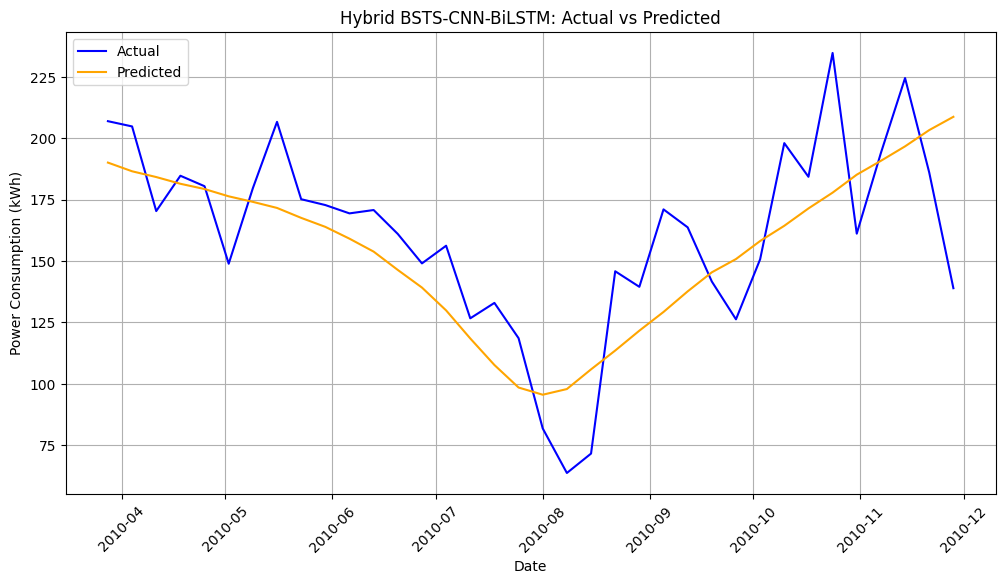

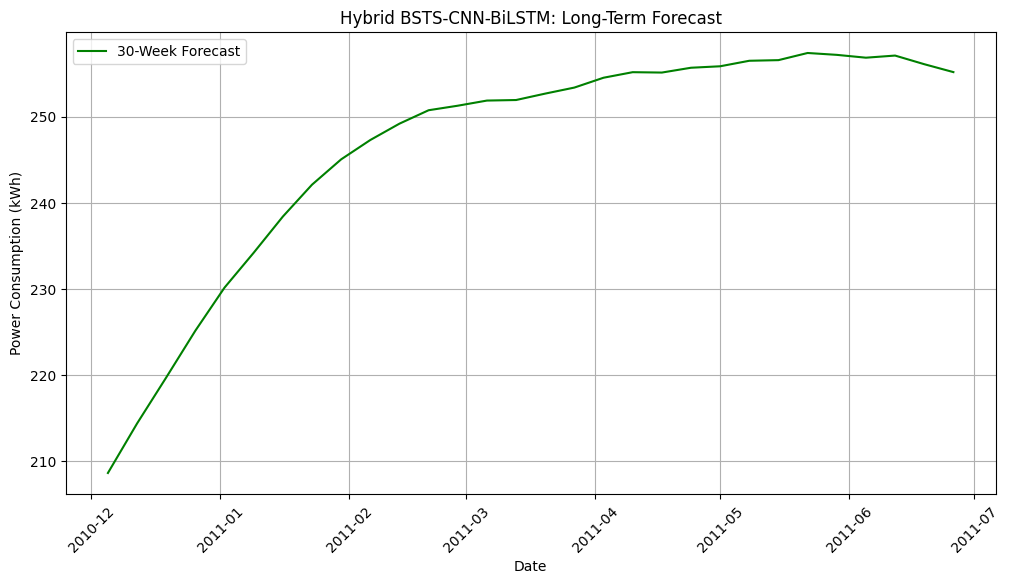

X shape: (177, 30, 3), y shape: (177,)
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.1576 - val_loss: 0.0328
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0401 - val_loss: 0.0222
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0602 - val_loss: 0.0182
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0450 - val_loss: 0.0230
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0378 - val_loss: 0.0394
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0376 - val_loss: 0.0410
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0348 - val_loss: 0.0296
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0353 - val_loss: 0.0214
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0383 - val_loss: 0.0200
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0316 - val_loss: 0.0235
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0381 - val_loss: 0.0301
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0399 - val_loss: 0.0310
Epoch 13/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 353ms/step - loss: 0.2072 - val_loss: 0.0323
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0815 - val_loss: 0.0106
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0284 - val_loss: 0.0422
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0369 - val_loss: 0.0449
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0307 - val_loss: 0.0144
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0181 - val_loss: 0.0090
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0208 - val_loss: 0.0081
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - loss: 0.0162 - val_loss: 0.0115
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.0145 - val_loss: 0.0120
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - loss: 0.0145 - val_loss: 0.0091
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 0.0126 - val_loss: 0.0107
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - loss: 0.0147 - val_loss: 0.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - loss: 0.4495 - val_loss: 0.2753
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.1603 - val_loss: 0.0489
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0402 - val_loss: 0.0244
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0600 - val_loss: 0.0240
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0525 - val_loss: 0.0140
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0352 - val_loss: 0.0283
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0369 - val_loss: 0.0352
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0395 - val_loss: 0.0299
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0342 - val_loss: 0.0203
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0280 - val_loss: 0.0136
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0313 - val_loss: 0.0110
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0267 - val_loss: 0.0100
Epoch 13/20

In [ ]:
# --- Main Pipeline ---
def main():
    # Load and preprocess data
    df = download_and_load_data()
    if df is None:
        return
    print("Columns:", df.columns.tolist())
    print("\nInitial data preview:\n", df.head())

    df_transformed = clean_and_transform_data(df)
    if df_transformed is None:
        return
    df_weekly = resample_to_period(df_transformed, 'W')
    print("\nWeekly data preview:\n", df_weekly.head())

    # Dictionary to store metrics for all models
    metrics_comparison = {}

    # Hybrid model with BSTS augmentation
    bsts_results = fit_bsts(df_weekly)
    if bsts_results is None:
        return
    df_weekly['trend'] = bsts_results['trend']
    df_weekly['seasonal'] = bsts_results['seasonal']
    feature_cols = ['trend', 'seasonal', 'day_of_week', 'month']
    X, y, target_scaler, feature_scaler = prepare_sequences(df_weekly, feature_cols=feature_cols)
    if X is None:
        return
    X_train, X_test, y_train, y_test = split_data(X, y)
    print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")

    # Train hybrid model
    model = build_cnn_bilstm(input_shape=(X_train.shape[1], X_train.shape[2]))
    model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = target_scaler.inverse_transform(y_pred_scaled)
    y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1))
    long_term_pred = forecast_long_term(model, X_test, steps=30, target_scaler=target_scaler)
    metrics = calculate_metrics(y_test_inv, y_pred)
    print("\nHybrid BSTS-CNN-BiLSTM Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    print("\nHybrid Long-Term Predictions (30 weeks):\n", pd.DataFrame(long_term_pred, columns=['Predicted_kWh']))
    metrics_comparison['Hybrid BSTS-CNN-BiLSTM'] = metrics

    # Save hybrid results
    results_df = pd.DataFrame({'Actual': y_test_inv.flatten(), 'Predicted': y_pred.flatten()})
    results_df.to_csv('hybrid_forecast_results.csv', index=False)
    long_term_df = pd.DataFrame(long_term_pred, columns=['Long_Term_Predicted_kWh'])
    long_term_df.to_csv('hybrid_long_term_forecast.csv', index=False)

    # Plot hybrid results
    last_date = df_weekly.index[-1]
    future_dates = pd.date_range(start=last_date, periods=31, freq='W')[1:]
    plt.figure(figsize=(12, 6))
    plt.plot(df_weekly.index[-len(y_test):], y_test_inv, label='Actual', color='blue')
    plt.plot(df_weekly.index[-len(y_test):], y_pred, label='Predicted', color='orange')
    plt.title('Hybrid BSTS-CNN-BiLSTM: Actual vs Predicted')
    plt.xlabel('Date')
    plt.ylabel('Power Consumption (kWh)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(future_dates, long_term_pred, label='30-Week Forecast', color='green')
    plt.title('Hybrid BSTS-CNN-BiLSTM: Long-Term Forecast')
    plt.xlabel('Date')
    plt.ylabel('Power Consumption (kWh)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.show()

    # Run baseline models
    # Prepare sequences without BSTS features for fair comparison
    X_base, y_base, target_scaler_base, _ = prepare_sequences(df_weekly, feature_cols=['day_of_week', 'month'])
    X_train_base, X_test_base, y_train_base, y_test_base = split_data(X_base, y_base)

    # CNN Baseline
    cnn_metrics = cnn_baseline(X_train_base, X_test_base, y_train_base, y_test_base, target_scaler_base)
    if cnn_metrics:
        metrics_comparison['CNN'] = cnn_metrics

    # BiLSTM Baseline
    bilstm_metrics = bilstm_baseline(X_train_base, X_test_base, y_train_base, y_test_base, target_scaler_base)
    if bilstm_metrics:
        metrics_comparison['BiLSTM'] = bilstm_metrics

    # LSTM Baseline
    lstm_metrics = lstm_baseline(X_train_base, X_test_base, y_train_base, y_test_base, target_scaler_base)
    if lstm_metrics:
        metrics_comparison['LSTM'] = lstm_metrics

    # BSTS Baseline
    bsts_metrics = bsts_baseline(df_weekly, y_test_base, target_scaler_base)
    if bsts_metrics:
        metrics_comparison['BSTS'] = bsts_metrics

    # ARIMA Baseline
    arima_metrics = arima_baseline(df_weekly, y_test_base, target_scaler_base)
    if arima_metrics:
        metrics_comparison['ARIMA'] = arima_metrics

    # Build and display comparison table
    metrics_df = pd.DataFrame(metrics_comparison).T
    # Filter out any non-numeric columns before applying float_format
    numeric_cols = metrics_df.select_dtypes(include=np.number).columns
    print("\nComparison of Model Performance Metrics:")
    print(metrics_df[numeric_cols].to_string(float_format="%.4f"))

if __name__ == "__main__":
    main()